#About Dataset
link https://www.kaggle.com/datasets/usgs/earthquake-database

Context


The National Earthquake Information Center (NEIC) determines the location and size of all significant earthquakes that occur worldwide and disseminates this information immediately to national and international agencies, scientists, critical facilities, and the general public. The NEIC compiles and provides to scientists and to the public an extensive seismic database that serves as a foundation for scientific research through the operation of modern digital national and global seismograph networks and cooperative international agreements. The NEIC is the national data center and archive for earthquake information.

##Imports

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf

Load the data

In [3]:
df = pd.read_csv("database.csv")

##Explore the data

In [4]:
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [5]:
df.isnull().sum()

,0
Date,0
Time,0
Latitude,0
Longitude,0
Type,0
Depth,0
Depth Error,18951
Depth Seismic Stations,16315
Magnitude,0
Magnitude Type,3


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

In [8]:
df.shape

(23412, 21)

##Preproseccing

In [13]:
df = df.drop(columns=["Horizontal Error","Horizontal Distance","Azimuthal Gap","Magnitude Seismic Stations","Magnitude Error","Depth Error",
"Depth Seismic Stations"])

In [21]:
df = df.fillna(df['Root Mean Square'].mean())

In [20]:
df = df.fillna(df['Magnitude Type'].mode())

In [22]:
df.isnull().sum()

,0
Date,0
Time,0
Latitude,0
Longitude,0
Type,0
Depth,0
Magnitude,0
Magnitude Type,0
Root Mean Square,0
ID,0


In [23]:
correlation_matrix = df.select_dtypes(include='number').corr()
display(correlation_matrix)

,Latitude,Longitude,Depth,Magnitude,Root Mean Square
Latitude,1.000000,0.203546,-0.081020,0.034987,-0.182088
Longitude,0.203546,1.000000,-0.085861,0.038579,-0.024286
Depth,-0.081020,-0.085861,1.000000,0.023457,-0.119145
Magnitude,0.034987,0.038579,0.023457,1.000000,0.065022
Root Mean Square,-0.182088,-0.024286,-0.119145,0.065022,1.000000


In [24]:
# you can use this fuc in any data

threshold = 0.8
highly_correlated_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            colname_i = correlation_matrix.columns[i]
            colname_j = correlation_matrix.columns[j]
            highly_correlated_pairs.append((colname_i, colname_j, correlation_matrix.iloc[i, j]))

# Display highly correlated pairs
if highly_correlated_pairs:
    print(f"Highly correlated columns (absolute correlation > {threshold}):")
    for col1, col2, corr_value in highly_correlated_pairs:
        print(f"- {col1} and {col2}: {corr_value:.4f}")
else:
    print("No highly correlated columns found above the specified threshold.")

No highly correlated columns found above the specified threshold.


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Latitude          23412 non-null  float64
 1   Longitude         23412 non-null  float64
 2   Type              23412 non-null  object 
 3   Depth             23412 non-null  float64
 4   Magnitude         23412 non-null  float64
 5   Magnitude Type    23412 non-null  object 
 6   Root Mean Square  23412 non-null  float64
 7   ID                23412 non-null  object 
 8   Source            23412 non-null  object 
 9   Location Source   23412 non-null  object 
 10  Magnitude Source  23412 non-null  object 
 11  Status            23412 non-null  int64  
dtypes: float64(5), int64(1), object(6)
memory usage: 2.1+ MB


In [31]:
df.head()


,Latitude,Longitude,Type,Depth,Magnitude,Magnitude Type,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,19.246,145.616,Earthquake,131.6,6.0,MW,1.022784,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,1.863,127.352,Earthquake,80.0,5.8,MW,1.022784,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,-20.579,-173.972,Earthquake,20.0,6.2,MW,1.022784,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,-59.076,-23.557,Earthquake,15.0,5.8,MW,1.022784,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,11.938,126.427,Earthquake,15.0,5.8,MW,1.022784,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [28]:
df = df.drop(columns=["Date"])

In [58]:
df = df.drop(columns=["ID"])

In [30]:
df = df.drop(columns=["Time"])

In [33]:
df["Type"].unique()

array(['Earthquake', 'Nuclear Explosion', 'Explosion', 'Rock Burst'],
      dtype=object)

In [34]:
df["Magnitude Type"].unique()

array(['MW', 'ML', 'MH', 'MS', 'MB', 'MWC', 'MD', 1.022783990318119,
       'MWB', 'MWW', 'MWR'], dtype=object)

In [37]:
df["Source"].unique()

array(['ISCGEM', 'ISCGEMSUP', 'OFFICIAL', 'CI', 'US', 'NC', 'GCMT', 'UW',
       'ATLAS', 'NN', 'SE', 'AK', 'PR'], dtype=object)

In [36]:
df["Location Source"].unique()

array(['ISCGEM', 'CI', 'US', 'H', 'U', 'G', 'NC', 'B', 'GCMT', 'AG', 'UW',
       'SPE', 'HVO', 'BRK', 'ATLAS', 'AGS', 'PGC', 'BOU', 'SLC', 'OTT',
       'AEI', 'AEIC', 'CASC', 'ISK', 'ATH', 'THE', 'ROM', 'MDD', 'WEL',
       'GUC', 'UNM', 'CSEM', 'RSPR', 'JMA', 'NN', 'CAR', 'SJA', 'TEH',
       'BEO', 'UCR', 'SE', 'TUL', 'TAP', 'THR', 'LIM', 'US_WEL', 'AK',
       'PR'], dtype=object)

In [38]:
df["Magnitude Source"].unique()

array(['ISCGEM', 'OFFICIAL', 'CI', 'US', '1020', 'BRK', 'NC', '1000',
       'GCMT', '1009', 'UW', '1023', 'ATLAS', 'HRV', 'PAR', 'NIED', 'NN',
       'SE', 'PGC', 'US_GCMT', 'US_PGC', 'AK', 'PR', 'GUC'], dtype=object)

In [41]:
df["Status"].unique()

array([1, 0])

In [40]:
df['Status'] = df['Status'].apply(lambda x:1 if x=="Automatic" else 0)

In [48]:
# you can also use this in any data

def OneHot(df,columns,prefixes):
  df = df.copy()
  for column, prefix in zip(columns, prefixes):
    dummies = pd.get_dummies(df[column],prefix=prefix)
    df = pd.concat([df,dummies],axis=1)
    df = df.drop(columns=[column],axis=1) # Drop the original column after creating dummies
  return df

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Latitude          23412 non-null  float64
 1   Longitude         23412 non-null  float64
 2   Type              23412 non-null  object 
 3   Depth             23412 non-null  float64
 4   Magnitude         23412 non-null  float64
 5   Magnitude Type    23412 non-null  object 
 6   Root Mean Square  23412 non-null  float64
 7   ID                23412 non-null  object 
 8   Source            23412 non-null  object 
 9   Location Source   23412 non-null  object 
 10  Magnitude Source  23412 non-null  object 
 11  Status            23412 non-null  int64  
dtypes: float64(5), int64(1), object(6)
memory usage: 2.1+ MB


In [49]:
df = OneHot(
    df,
    ['Type', 'Magnitude Type', 'Source', 'Location Source', 'Magnitude Source'],
    ['t', 'mt', 's', 'ls', 'ms']
)

In [51]:
df.head()

,Latitude,Longitude,Depth,Magnitude,Root Mean Square,ID,Status,t_Earthquake,t_Explosion,t_Nuclear Explosion,...,ms_NN,ms_OFFICIAL,ms_PAR,ms_PGC,ms_PR,ms_SE,ms_US,ms_US_GCMT,ms_US_PGC,ms_UW
0,19.246,145.616,131.6,6.0,1.022784,ISCGEM860706,1,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.863,127.352,80.0,5.8,1.022784,ISCGEM860737,1,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-20.579,-173.972,20.0,6.2,1.022784,ISCGEM860762,1,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-59.076,-23.557,15.0,5.8,1.022784,ISCGEM860856,1,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,11.938,126.427,15.0,5.8,1.022784,ISCGEM860890,1,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [52]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
display(df.head())

,Latitude,Longitude,Depth,Magnitude,Root Mean Square,ID,Status,t_Earthquake,t_Explosion,t_Nuclear Explosion,...,ms_NN,ms_OFFICIAL,ms_PAR,ms_PGC,ms_PR,ms_SE,ms_US,ms_US_GCMT,ms_US_PGC,ms_UW
0,19.246,145.616,131.6,6.0,1.022784,ISCGEM860706,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1.863,127.352,80.0,5.8,1.022784,ISCGEM860737,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-20.579,-173.972,20.0,6.2,1.022784,ISCGEM860762,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-59.076,-23.557,15.0,5.8,1.022784,ISCGEM860856,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,11.938,126.427,15.0,5.8,1.022784,ISCGEM860890,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
df.dtypes

,0
Latitude,float64
Longitude,float64
Depth,float64
Magnitude,float64
Root Mean Square,float64
...,...
ms_SE,int64
ms_US,int64
ms_US_GCMT,int64
ms_US_PGC,int64


##Training and Building the model

In [59]:
y = df.loc[:, 'Status']
X = df.drop('Status', axis=1)

In [60]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=56)

In [62]:
X.shape

(23412, 105)

In [63]:
df.head()

,Latitude,Longitude,Depth,Magnitude,Root Mean Square,Status,t_Earthquake,t_Explosion,t_Nuclear Explosion,t_Rock Burst,...,ms_NN,ms_OFFICIAL,ms_PAR,ms_PGC,ms_PR,ms_SE,ms_US,ms_US_GCMT,ms_US_PGC,ms_UW
0,19.246,145.616,131.6,6.0,1.022784,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1.863,127.352,80.0,5.8,1.022784,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-20.579,-173.972,20.0,6.2,1.022784,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-59.076,-23.557,15.0,5.8,1.022784,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,11.938,126.427,15.0,5.8,1.022784,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [68]:
inputs = tf.keras.Input(shape=(105,))
x = tf.keras.layers.Dense(128, activation='relu')(inputs)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(32, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')]
)


batch_size = 32
epochs = 30

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[tf.keras.callbacks.ReduceLROnPlateau()],
    verbose=0
)

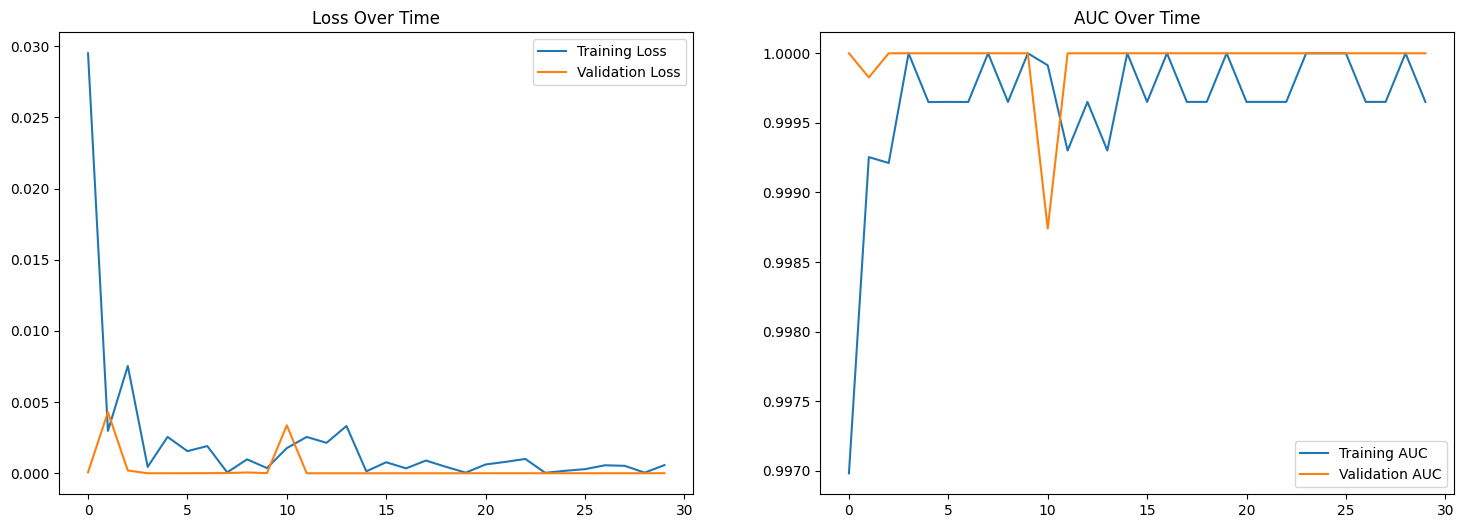

In [69]:
plt.figure(figsize=(18, 6))

epochs_range = range(epochs)
train_loss, val_loss = history.history['loss'], history.history['val_loss']
train_auc, val_auc = history.history['auc'], history.history['val_auc']

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Loss Over Time")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_auc, label="Training AUC")
plt.plot(epochs_range, val_auc, label="Validation AUC")
plt.legend()
plt.title("AUC Over Time")

plt.show()

In [70]:
model.evaluate(X_test, y_test)

220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 1.0000 - loss: 3.2497e-04


[0.0002873849880415946, 1.0]

:}